# Model Development and Testing

In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import numpy as np
from collections import OrderedDict

### Data preparation

The first step in the process is to format the data for a neural network based model. All of the categorical variables must be one-hot encoded.

Step 1: Determine categorical and quantitative variables. This is easy to do based on the output of the describe function from pandas.

In [2]:
data = pd.read_csv('project_data.csv')

quantitative = set((data.drop('Booking_ID', axis=1).describe().columns))
categorical = set((data.drop(['Booking_ID', 'arrival_date', 'booking_status'], axis=1).columns)) - quantitative

Step 2: Convert the categorical variables to one-hot encoded versions. Pandas has a built in "get dummies" function to do this, but I am feeling ambitious. Let's implement this from scratch.

In [3]:
for cat in list(categorical):
    # Find the unique values for the column
    unique_vals = data[cat].unique()
    
    # For each unique value, create a new column with the value name
    for val in unique_vals:
        data[val] = np.where(data[cat].values==val, 1, 0)


In [4]:
encoded_data = data.drop(list(categorical)+['Booking_ID'], axis = 1, inplace=False)

In [5]:
print(encoded_data.head(5))

   no_of_adults  no_of_children  no_of_weekend_nights  no_of_week_nights  \
0             2               0                     1                  2   
1             2               0                     2                  3   
2             1               0                     2                  1   
3             2               0                     0                  2   
4             2               0                     1                  1   

   required_car_parking_space  lead_time arrival_date  repeated_guest  \
0                           0        224   2017-10-02               0   
1                           0          5   2018-11-06               0   
2                           0          1   2018-02-28               0   
3                           0        211   2018-05-20               0   
4                           0         48   2018-04-11               0   

   no_of_previous_cancellations  no_of_previous_bookings_not_canceled  ...  \
0                         

Now that the categorical variables have been one-hot encoded, we can tackle the arrival_date variable. I want to extract a the month from this because I suspect there may be seasonality to the data within this time frame.

In [6]:
encoded_data['arrival_date'] = [int(date.split('-')[1]) for date in encoded_data['arrival_date'].values]

In [7]:
encoded_data['arrival_date']

0        10
1        11
2         2
3         5
4         4
         ..
36233     8
36234    10
36235     7
36236     4
36237    12
Name: arrival_date, Length: 36238, dtype: int64

Now the booking status variable must be transformed to a numerical representation.

In [8]:
encoded_data[encoded_data['booking_status'] == "not_canceled"] = 0
encoded_data[encoded_data['booking_status'] == "canceled"] = 1

Looks like everything is model ready. Let's take a look at the dataset again to be sure.

In [9]:
encoded_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36238 entries, 0 to 36237
Data columns (total 29 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36238 non-null  int64  
 1   no_of_children                        36238 non-null  int64  
 2   no_of_weekend_nights                  36238 non-null  int64  
 3   no_of_week_nights                     36238 non-null  int64  
 4   required_car_parking_space            36238 non-null  int64  
 5   lead_time                             36238 non-null  int64  
 6   arrival_date                          36238 non-null  int64  
 7   repeated_guest                        36238 non-null  int64  
 8   no_of_previous_cancellations          36238 non-null  int64  
 9   no_of_previous_bookings_not_canceled  36238 non-null  int64  
 10  avg_price_per_room                    36238 non-null  float64
 11  no_of_special_r

Beautiful...

### Model Development

I want to build a model handling framework to make it easier to test and compare different model architectures. To do so, I will build a Model Handler class.

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, roc_curve, roc_auc_score, precision_score

In [20]:
class ModelHandler():
    def __init__(self, X: pd.DataFrame, Y: pd.Series, architecture: nn.Sequential, optimizer: optim = optim.AdamW, loss_fn = nn.MSELoss()):
        self.X = self._transform_data(X)
        self.Y = self._transform_data(Y, torch.long)
        self._split_data()
        self.model = architecture
        self.optimizer = optimizer
        self.loss_fn = loss_fn().to('cuda')

        # Utilize the gpu for training
        self.model.to('cuda')
        self.loss_fn.to('cuda')

    def train(self, n_epochs, lr = 1e-3):
        self.training_losses = []
        self.test_losses = []
        self.optimizer = self.optimizer(self.model.parameters(), lr)
        
        for epoch in range(1, n_epochs+1):
            p_train = self.model(self.X_train).to('cuda')
            train_loss = self.loss_fn(p_train, self.Y_train)
            self.training_losses.append(train_loss.to('cpu').item())

            p_test = self.model(self.X_test)
            loss_test = self.loss_fn(p_test, self.Y_test)
            self.test_losses.append(loss_test.to('cpu').item())

            self.optimizer.zero_grad()
            train_loss.backward() # <2>
            self.optimizer.step()

            if epoch == 1 or epoch % 1000 == 0:
                print(f"Epoch {epoch}, Training loss {train_loss.item():.4f},"
                        f" Test loss {loss_test.item():.4f}")
            
        self._plot_losses(self.training_losses, self.test_losses, 'Training vs. Test Loss')

    def eval_model(self, labels):
        self.labels = labels

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        self.predictions = []
        correct_preds = 0
        for idx in range(len(self.X_val)):
            probs = torch.exp(self.model(self.X_val[idx]))
            pred = torch.argmax(probs).to('cpu').item()
            self.predictions.append(pred)
            true_val = self.Y_val[idx].item()
            #print(pred, true_val)
            if pred == true_val:
                correct_preds+=1

        for i, dir in enumerate(self.Y_val):
            if self.predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def _plot_losses(self, train_losses, test_losses, title):
        x = np.array([i for i in range(1, len(train_losses)+1)])
        y1 = np.array(train_losses)
        y2 = np.array(test_losses)

        plt.plot(x, y1, label = "Train Loss")
        plt.plot(x, y2, label = "Test Loss")
        plt.legend(loc="upper right")
        plt.title(title)

        plt.show()

    def _split_data(self):
        n_samples = len(self.X)
        n_test = int(0.20 * n_samples)
        n_val = int(0.10 * n_samples)

        shuffled_indices = torch.randperm(n_samples)

        train_indices = shuffled_indices[:-n_val-n_test]
        test_indices = shuffled_indices[-n_val-n_test:-n_val]
        val_indices = shuffled_indices[-n_val:]

        # Verify the indices are all unique
        train_set = set(train_indices.numpy())
        test_set = set(test_indices.numpy())
        val_set = set(val_indices.numpy())

        if not len(train_set & test_set) and not len(train_set & val_set) and not len(test_set & val_set):
            print("Train, Test, and Validation data is verified as unique.")
        else:
            print("DATA LEAK.")

        #Assign train data
        self.X_train = self.X[train_indices].to('cuda')
        self.Y_train = self.Y[train_indices].to('cuda')

        #Assign train data
        self.X_test = self.X[test_indices].to('cuda')
        self.Y_test = self.Y[test_indices].to('cuda')
        
        #Assign val data
        self.X_val = self.X[val_indices].to('cuda')
        self.Y_val = self.Y[val_indices].to('cuda')

    def _transform_data(self, data, type = torch.float):
        return torch.tensor(data.to_numpy()).to(type)

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.Y_val))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.Y_val))*100}')

    def _plot_cm(self):
        fig, axes = plt.subplots(1,2,figsize=(15,10))
        axes = axes.flatten()

        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues,ax=axes[0])

        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')


        axes[1].plot(self.fpr, self.tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {self.auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

        plt.show()

    def _compute_metrics(self):
        Y = self.Y_val.cpu()

        # Calculate the ROC curve points
        self.fpr, self.tpr, self.thresholds = roc_curve(Y, self.predictions)

        # Calculate the AUC
        self.auc = roc_auc_score(Y, self.predictions)

        self.accuracy = f'{accuracy_score(Y, self.predictions)*100:.2f}%'

        # Compute recall
        self.recall = self.confusion_matrix['true_positive'] / (self.confusion_matrix['true_positive'] + self.confusion_matrix['false_negative'])

        # Compute precision
        self.precision = precision_score(Y, self.predictions)

        # Compute F1-Score
        self.f1_score = f'{(2*self.precision*self.recall)/(self.precision+self.recall):.2f}'

        print(f'\nAccuracy: {self.accuracy}')
        print(f'\nRecall: {self.recall}')
        print(f'\nPrecision: {self.precision}')
        print(f'\nF1-Score: {self.f1_score}')



Set up some variables that will be used across all models.

In [12]:
torch.seed()
X = encoded_data.drop(["booking_status"], axis=1)
Y = encoded_data['booking_status'].astype(np.int64)
input_features = len(encoded_data.drop('booking_status', axis=1).columns)
labels = ['Not Canceled', 'Canceled']

Start with a very basic model that uses MSELoss and a linear output layer.

Train, Test, and Validation data is verified as unique.
Epoch 1, Training loss 0.6469, Test loss 0.6464
Epoch 1000, Training loss 0.6303, Test loss 0.6307
Epoch 2000, Training loss 0.6139, Test loss 0.6133
Epoch 3000, Training loss 0.5977, Test loss 0.5973
Epoch 4000, Training loss 0.5798, Test loss 0.5785
Epoch 5000, Training loss 0.5619, Test loss 0.5607
Epoch 6000, Training loss 0.5432, Test loss 0.5430
Epoch 7000, Training loss 0.5240, Test loss 0.5228
Epoch 8000, Training loss 0.5034, Test loss 0.5036
Epoch 9000, Training loss 0.4833, Test loss 0.4821
Epoch 10000, Training loss 0.4625, Test loss 0.4613


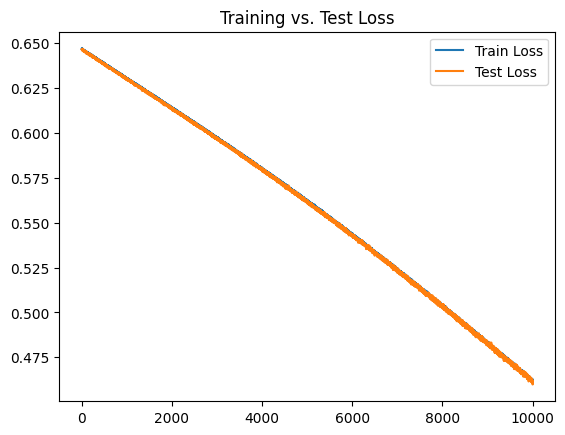

Number of Canceled Predictions: 1067
Number of Not Canceled Predictions: 2556
Percent Canceled Predictions: 29.450731438034776
Percent Not Canceled Predictions: 70.54926856196522

Accuracy: 97.79%

Recall: 0.93025283347864

Precision: 1.0

F1-Score: 0.96


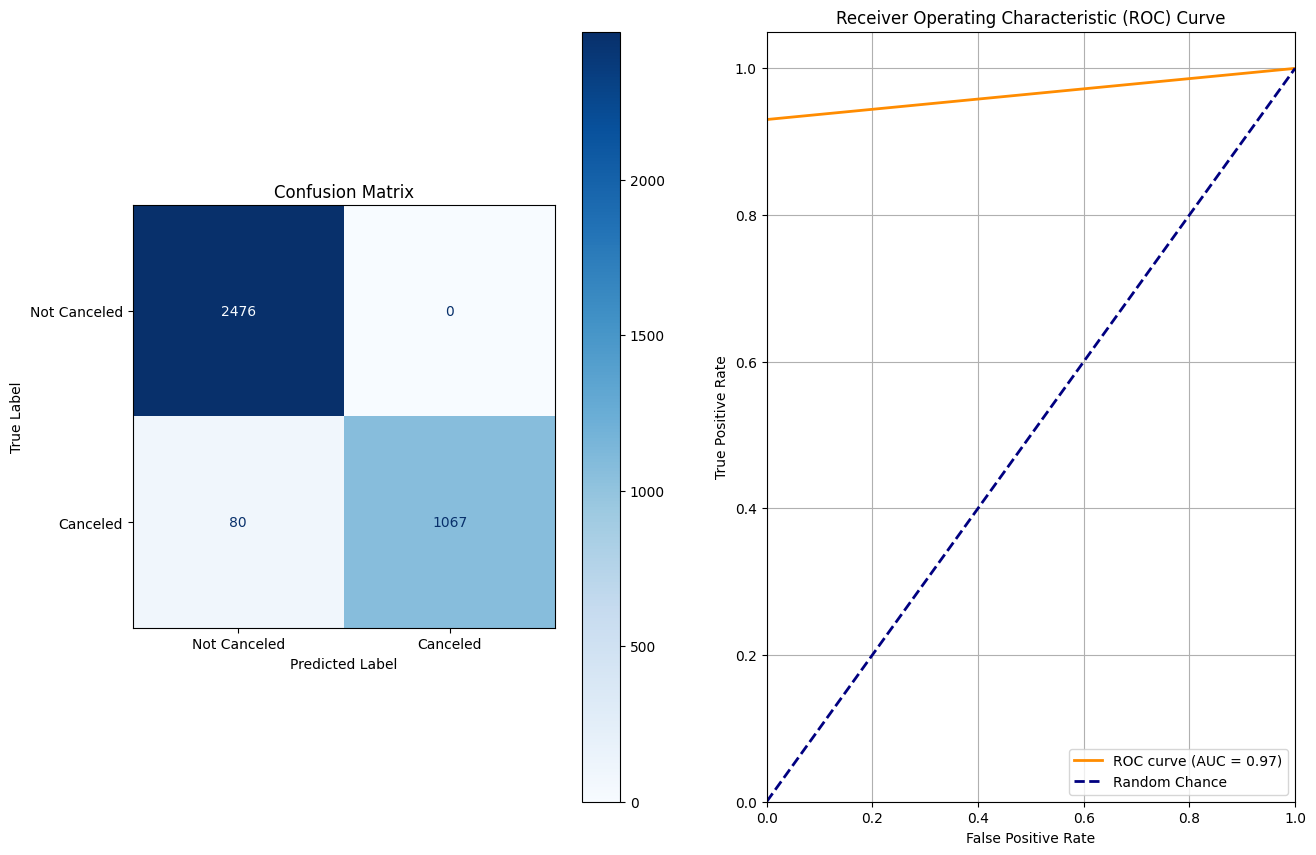

In [21]:
model_1 = nn.Sequential(OrderedDict([
    ('hidden_linear1', nn.Linear(in_features=input_features, out_features=10)),
    ('dropout1', nn.Dropout(0.2)),
    ('hidden_linear2', nn.Linear(in_features=10, out_features=5)),
    ('hidden_activation', nn.Tanh()),
    ('output_linear', nn.Linear(in_features=5, out_features=2))
]))

model_1 = ModelHandler(
    X = X,
    Y = Y,
    architecture = model_1,
    optimizer = optim.SGD,
    loss_fn = nn.CrossEntropyLoss
    )

model_1.train(10000, 1e-4)
model_1.eval_model(labels)

Train, Test, and Validation data is verified as unique.
Epoch 1, Training loss 0.6754, Test loss 0.6752


c:\Users\water\anaconda3\envs\DSE6211\Lib\site-packages\torch\nn\modules\module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 1000, Training loss 0.3133, Test loss 0.3133
Epoch 2000, Training loss 0.3133, Test loss 0.3133
Epoch 3000, Training loss 0.3133, Test loss 0.3133
Epoch 4000, Training loss 0.3133, Test loss 0.3133
Epoch 5000, Training loss 0.3133, Test loss 0.3133


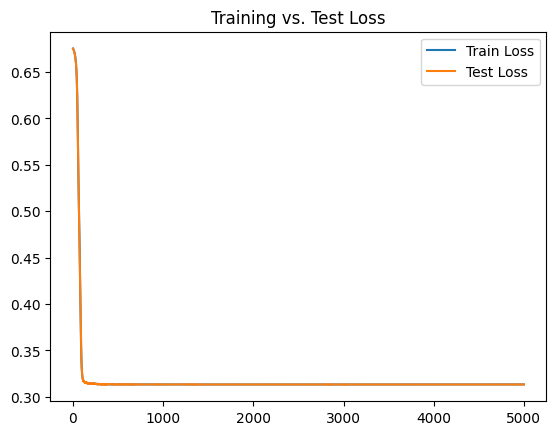

Number of Canceled Predictions: 1202
Number of Not Canceled Predictions: 2421
Percent Canceled Predictions: 33.17692520011041
Percent Not Canceled Predictions: 66.8230747998896

Accuracy: 100.00%

Recall: 1.0

Precision: 1.0

F1-Score: 1.00


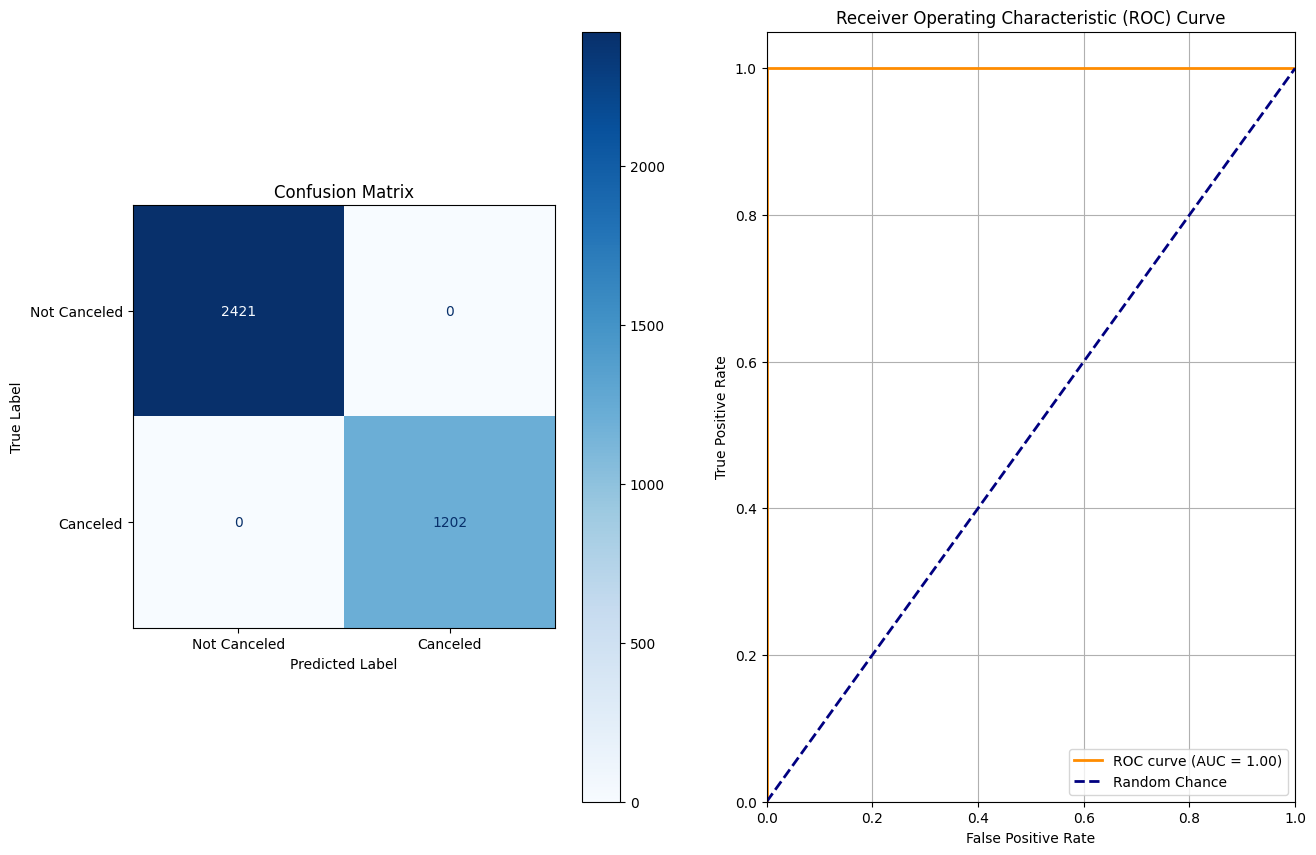

In [14]:
model_2 = nn.Sequential(OrderedDict([
    ('hidden_linear1', nn.Linear(in_features=input_features, out_features=200)),
    ('hidden_linear2', nn.Linear(in_features=200, out_features=500)),
    ('relu1', nn.ReLU()),
    ('dropout1', nn.Dropout(0.2)),
    ('hidden_linear3', nn.Linear(in_features=500, out_features=400)),
    ('relu2', nn.ReLU()),
    ('dropout2', nn.Dropout(0.3)),
    ('hidden_linear4', nn.Linear(in_features=400, out_features=200)),
    ('lrelu1', nn.LeakyReLU()),
    ('dropout3', nn.Dropout(0.3)),
    ('hidden_linear6', nn.Linear(in_features=200, out_features=150)),
    ('relu3', nn.ReLU()),
    ('dropout4', nn.Dropout(0.2)),
    ('hidden_linear7', nn.Linear(in_features=150, out_features=100)),
    ('hidden_linear8', nn.Linear(in_features=100, out_features=50)),
    ('relu4', nn.ReLU()),
    ('dropout5', nn.Dropout(0.3)),
    ('hidden_linear9', nn.Linear(in_features=50, out_features=20)),
    ('lrelu2', nn.LeakyReLU()),
    ('dropout6', nn.Dropout(0.3)),
    ('hidden_linear10', nn.Linear(in_features=20, out_features=2)),
    ('output', nn.Softmax())
]))

model_2 = ModelHandler(
    X = X,
    Y = Y,
    architecture = model_2,
    optimizer = optim.AdamW,
    loss_fn = nn.CrossEntropyLoss
    )

model_2.train(5000, 1e-4)
model_2.eval_model(labels)


Train, Test, and Validation data is verified as unique.
Epoch 1, Training loss 0.7534, Test loss 0.7547


c:\Users\water\anaconda3\envs\DSE6211\Lib\site-packages\torch\nn\modules\module.py:1773: UserWarning: Implicit dimension choice for log_softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epoch 1000, Training loss 0.0015, Test loss 0.0015
Epoch 2000, Training loss 0.0002, Test loss 0.0002
Epoch 3000, Training loss 0.0001, Test loss 0.0001
Epoch 4000, Training loss 0.0000, Test loss 0.0000
Epoch 5000, Training loss 0.0000, Test loss 0.0000


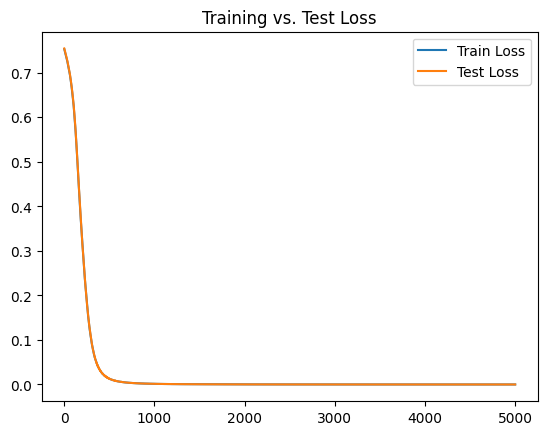

Number of Canceled Predictions: 1163
Number of Not Canceled Predictions: 2460
Percent Canceled Predictions: 32.10046922439967
Percent Not Canceled Predictions: 67.89953077560034

Accuracy: 100.00%

Recall: 1.0

Precision: 1.0

F1-Score: 1.00


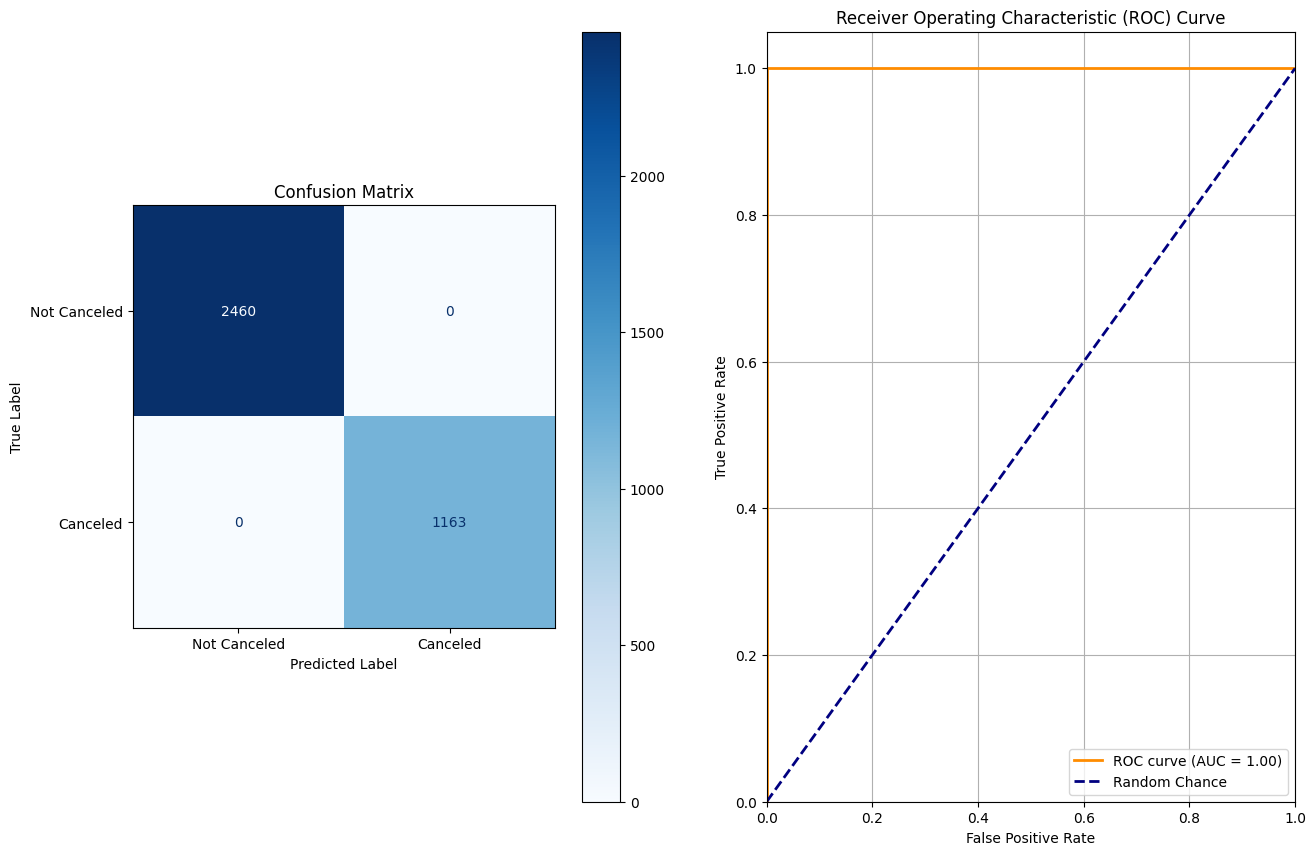

In [15]:
model_3 = nn.Sequential(OrderedDict([
    ('hidden_linear1', nn.Linear(in_features=input_features, out_features=20)),
    ('hidden_linear2', nn.Linear(in_features=20, out_features=50)),
    ('dropout1', nn.Dropout(0.2)),
    ('hidden_linear3', nn.Linear(in_features=50, out_features=40)),
    ('dropout2', nn.Dropout(0.3)),
    ('hidden_linear4', nn.Linear(in_features=40, out_features=20)),
    ('hidden_activation', nn.LeakyReLU()),
    ('hidden_linear6', nn.Linear(in_features=20, out_features=2)),
    ('output', nn.LogSoftmax())
]))

model_3 = ModelHandler(
    X = X,
    Y = Y,
    architecture = model_3,
    optimizer = optim.AdamW,
    loss_fn = nn.NLLLoss
    )

model_3.train(5000, 1e-4)
model_3.eval_model(labels)
